# Binary Treatment Causal Analysis


In [9]:
import warnings
import re
import sys
from pathlib import Path

import graphviz
import numpy as np
import pandas as pd
from dowhy import CausalModel
from IPython.display import display
from sklearn.exceptions import DataConversionWarning
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore", category=DataConversionWarning)


def find_repo_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "utils" / "statistical_tests.py").exists():
            return candidate
    raise RuntimeError("Could not find repo root containing utils/statistical_tests.py")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils import statistical_tests as tests


In [10]:
INPUT_FILE = "alerts_with_lib_category_and_apk_size_semgrep.csv"


def normalize_verdict(value):
    normalized = str(value).strip().lower()
    if normalized in {"1", "true"}:
        return 1
    if normalized in {"0", "false"}:
        return 0
    raise ValueError(f"Unsupported verdict value: {value!r}")


def normalize_rule_id(value):
    if pd.isna(value):
        return "missing"
    value = str(value).strip()
    if not value:
        return "missing"
    return re.sub(r"[^0-9A-Za-z_]+", "_", value)


def add_rule_id_columns(data):
    rule_id_dummies = pd.get_dummies(data["rule_id"], prefix="rule_id", drop_first=True, dtype=int)
    return pd.concat([data, rule_id_dummies], axis=1), list(rule_id_dummies.columns)


df = pd.read_csv(INPUT_FILE)
print("Original rows:", len(df))

df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)].copy()
print("After removing obfuscated:", len(df))

df["verdict"] = df["verdict"].apply(normalize_verdict)
df["is_3rd_party"] = (~df["code_location"].isin(["developer_written"])).astype(int)
df["is_third_party"] = df["is_3rd_party"]
df["lib_category"] = df["code_location"].apply(lambda x: x if x != "developer_written" else "source")

rule_id_source_column = "rule_id" if "rule_id" in df.columns else "ruleId"
df["rule_id"] = df[rule_id_source_column].apply(normalize_rule_id)

# Combined treatment: 1 means all classified alerts are reported; 0 means developer-written-only alerts are reported.
df_all = df.copy()
df_all["combined"] = 1
df_developer_written = df[df["code_location"] == "developer_written"].copy()
df_developer_written["combined"] = 0
df = pd.concat([df_all, df_developer_written], ignore_index=True)

print("\nis_3rd_party counts:")
print(df["is_3rd_party"].value_counts())
print("\nCombined counts:")
print(df["combined"].value_counts())
print("\nVerdict value counts:")
print(df["verdict"].value_counts())
print("\nCode location value counts:")
print(df["code_location"].value_counts())
print("\nTop rule_id counts:")
print(df["rule_id"].value_counts().head(20))


Original rows: 14590
After removing obfuscated: 14590

is_3rd_party counts:
is_3rd_party
1    12830
0     3520
Name: count, dtype: int64

Combined counts:
combined
1    14590
0     1760
Name: count, dtype: int64

Verdict value counts:
verdict
1    10805
0     5545
Name: count, dtype: int64

Code location value counts:
code_location
others               5787
Android              4769
developer_written    3520
Utilities            1743
SocialMedia           294
Advertising           135
Cloud                  75
Analytics              27
Name: count, dtype: int64

Top rule_id counts:
rule_id
java_lang_security_audit_crypto_weak_random_weak_random                                                    3795
java_lang_security_audit_crypto_use_of_md5_use_of_md5                                                      2527
gitlab_find_sec_bugs_CIPHER_INTEGRITY_1                                                                    1691
java_lang_security_audit_crypto_use_of_sha1_use_of_sha1            

In [11]:
category_order = [
    "<100",
    "100-500",
    "500-1k",
    "1k-5k",
    "5k-10k",
    "10k-50k",
    "50k-100k",
    "100k-500k",
    "500k-1M",
    "1M-5M",
    ">5M",
]

popularity_column = "app_popularity" if "app_popularity" in df.columns else "apk_category"
df["app_popularity_encoded"] = pd.Categorical(
    df[popularity_column],
    categories=category_order,
    ordered=True,
).codes

scaler = RobustScaler()
df["apk_size_scaled"] = scaler.fit_transform(df[["apk_size"]])

df, rule_id = add_rule_id_columns(df)

print("Popularity column:", popularity_column)
print("Rule ID effect modifier columns:", len(rule_id))
print(rule_id[:20])


Popularity column: apk_category
Rule ID effect modifier columns: 23
['rule_id_gitlab_find_sec_bugs_RSA_NO_PADDING_1', 'rule_id_java_lang_security_audit_cbc_padding_oracle_cbc_padding_oracle', 'rule_id_java_lang_security_audit_crypto_des_is_deprecated_des_is_deprecated', 'rule_id_java_lang_security_audit_crypto_desede_is_deprecated_desede_is_deprecated', 'rule_id_java_lang_security_audit_crypto_ecb_cipher_ecb_cipher', 'rule_id_java_lang_security_audit_crypto_no_null_cipher_no_null_cipher', 'rule_id_java_lang_security_audit_crypto_no_static_initialization_vector_no_static_initialization_vector', 'rule_id_java_lang_security_audit_crypto_rsa_no_padding_rsa_no_padding', 'rule_id_java_lang_security_audit_crypto_ssl_avoid_implementing_custom_digests_avoid_implementing_custom_digests', 'rule_id_java_lang_security_audit_crypto_ssl_defaulthttpclient_is_deprecated_defaulthttpclient_is_deprecated', 'rule_id_java_lang_security_audit_crypto_ssl_insecure_hostname_verifier_insecure_hostname_verifier',

In [12]:
# def all_correlation_tests():
#     tests.logistic_regression_binary_to_binary(df, "is_3rd_party", "combined")
#     tests.chi_square_test_cat_to_binary(df, "is_3rd_party", "combined")

#     tests.logistic_regression_binary_to_binary(df, "is_3rd_party", "verdict")
#     tests.chi_square_test_cat_to_binary(df, "is_3rd_party", "verdict")

#     tests.logistic_regression_numeric_to_binary(df, "app_popularity_encoded", "combined")
#     tests.chi_square_test_cat_to_binary(df, "app_popularity_encoded", "combined")

#     tests.logistic_regression_numeric_to_binary(df, "app_popularity_encoded", "verdict")
#     tests.chi_square_test_cat_to_binary(df, "app_popularity_encoded", "verdict")

#     tests.chi_square_test_cat_to_binary(df, "rule_id", "verdict")

#     tests.logistic_regression_binary_to_binary(df, "combined", "verdict")
#     tests.correlation_test_treatment_to_outcome(df)


# all_correlation_tests()


In [13]:
def make_rule_id_edges(targets):
    return "\n".join(
        f"    {column} -> {target};" for column in rule_id for target in targets
    )


def make_graph(edge_lines, rule_id_targets=None):
    rule_id_edges = make_rule_id_edges(rule_id_targets or [])
    body = "\n".join(edge_lines)
    if rule_id_edges:
        body = f"{body}\n{rule_id_edges}"
    return f"""
digraph {{
{body}
}}
"""


def print_refutation(method, ref):
    print(f"\nRefuter: {method}")
    if isinstance(ref, list):
        for item in ref:
            print(item)
    else:
        print(ref)


def get_refutation_value(ref, attribute):
    if isinstance(ref, list):
        return [getattr(item, attribute, None) for item in ref]
    return getattr(ref, attribute, None)


def estimate_effect_for_config(model, identified_estimand, method_name):
    estimate_kwargs = {
        "method_name": method_name,
        "target_units": "ate",
        "test_significance": True,
    }

    if method_name == "backdoor.propensity_score_matching":
        estimate_kwargs["confidence_intervals"] = "bootstrap"
        estimate_kwargs["method_params"] = {
            "num_simulations": 300,
            "sample_size_fraction": 1.0,
            "confidence_level": 0.95,
        }

    return model.estimate_effect(identified_estimand, **estimate_kwargs)


def run_refutation_tests(model, identified_estimand, estimate):
    ref_rows = []
    refutation_methods = [
        "random_common_cause",
        "placebo_treatment_refuter",
        "data_subset_refuter",
        "dummy_outcome_refuter",
    ]

    for method in refutation_methods:
        try:
            if method == "placebo_treatment_refuter":
                ref = model.refute_estimate(
                    identified_estimand,
                    estimate,
                    method_name=method,
                    placebo_type="permute",
                    num_simulations=200,
                )
            elif method == "data_subset_refuter":
                ref = model.refute_estimate(
                    identified_estimand,
                    estimate,
                    method_name=method,
                    subset_fraction=0.8,
                    num_simulations=200,
                )
            elif method == "dummy_outcome_refuter":
                ref = model.refute_estimate(
                    identified_estimand,
                    estimate,
                    method_name=method,
                    num_simulations=200,
                )
            else:
                ref = model.refute_estimate(identified_estimand, estimate, method_name=method)

            print_refutation(method, ref)
            ref_rows.append({
                "refuter": method,
                "new_effect": get_refutation_value(ref, "new_effect"),
                "p_value": get_refutation_value(ref, "p_value"),
                "error": None,
            })
        except Exception as exc:
            print(f"\nRefuter: {method}")
            print(f"Skipped because DoWhy could not run it for this estimand: {type(exc).__name__}: {exc}")
            ref_rows.append({
                "refuter": method,
                "new_effect": None,
                "p_value": None,
                "error": f"{type(exc).__name__}: {exc}",
            })
    return ref_rows


def run_causal_analysis(config):
    print("\n" + "=" * 90)
    print(config["name"])
    print("=" * 90)

    display_graph = make_graph(config["display_edges"], config.get("display_rule_id_targets", []))
    model_graph = make_graph(config["model_edges"], config.get("model_rule_id_targets", []))
    display(graphviz.Source(display_graph))

    common_causes = config["common_causes"]
    effect_modifiers = config.get("effect_modifiers", [])
    method_name = config["method_name"]

    print("Common causes:", common_causes)
    print("Effect modifiers:", effect_modifiers if effect_modifiers else "None")
    print("Estimator:", method_name)

    analysis_df = df.drop(columns=["propensity_score"], errors="ignore").copy()

    model = CausalModel(
        data=analysis_df,
        treatment="combined",
        outcome="verdict",
        graph=model_graph.replace("\n", " "),
        common_causes=common_causes,
        effect_modifiers=effect_modifiers or None,
    )

    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    print("\n------- Identified estimand -------")
    print(identified_estimand)

    estimate = estimate_effect_for_config(model, identified_estimand, method_name)

    print("\n------- Causal effect estimate -------")
    print(estimate)
    estimate.interpret(method_name="textual_effect_interpreter")

    ref_rows = run_refutation_tests(model, identified_estimand, estimate)

    return {
        "graph": config["name"],
        "estimator": method_name,
        "estimate": float(estimate.value),
        "common_causes": common_causes,
        "effect_modifiers": effect_modifiers,
        "identified_estimand": identified_estimand,
        "estimate_object": estimate,
        "refutations": ref_rows,
    }


In [14]:
GRAPH_CONFIGS = [
    {
        "name": "Graph 1: app popularity confounder",
        "display_edges": [
            "    combined -> verdict;",
            "    app_popularity_encoded -> combined;",
            "    app_popularity_encoded -> verdict;",
        ],
        "model_edges": [
            "    combined -> verdict;",
            "    app_popularity_encoded -> combined;",
            "    app_popularity_encoded -> verdict;",
        ],
        "common_causes": ["app_popularity_encoded"],
        "effect_modifiers": [],
        "method_name": "backdoor.propensity_score_matching",
    },
    {
        "name": "Graph 2: app popularity confounder with rule_id effect modification",
        "display_edges": [
            "    combined -> verdict;",
            "    app_popularity_encoded -> combined;",
            "    app_popularity_encoded -> verdict;",
            "    rule_id -> verdict;",
        ],
        "model_edges": [
            "    combined -> verdict;",
            "    app_popularity_encoded -> combined;",
            "    app_popularity_encoded -> verdict;",
        ],
        "model_rule_id_targets": ["verdict"],
        "common_causes": ["app_popularity_encoded"],
        "effect_modifiers": rule_id,
        "method_name": "backdoor.propensity_score_matching",
    },
    {
        "name": "Graph 3: APK size confounder",
        "display_edges": [
            "    combined -> verdict;",
            "    apk_size_scaled -> combined;",
            "    apk_size_scaled -> verdict;",
        ],
        "model_edges": [
            "    combined -> verdict;",
            "    apk_size_scaled -> combined;",
            "    apk_size_scaled -> verdict;",
        ],
        "common_causes": ["apk_size_scaled"],
        "effect_modifiers": [],
        "method_name": "backdoor.propensity_score_matching",
    },
    {
        "name": "Graph 4: APK size confounder with rule_id effect modification",
        "display_edges": [
            "    combined -> verdict;",
            "    apk_size_scaled -> combined;",
            "    apk_size_scaled -> verdict;",
            "    rule_id -> verdict;",
        ],
        "model_edges": [
            "    combined -> verdict;",
            "    apk_size_scaled -> combined;",
            "    apk_size_scaled -> verdict;",
        ],
        "model_rule_id_targets": ["verdict"],
        "common_causes": ["apk_size_scaled"],
        "effect_modifiers": rule_id,
        "method_name": "backdoor.propensity_score_matching",
    },
    {
        "name": "Graph 5: APK size and app popularity confounders",
        "display_edges": [
            "    combined -> verdict;",
            "    apk_size_scaled -> combined;",
            "    apk_size_scaled -> verdict;",
            "    app_popularity_encoded -> combined;",
            "    app_popularity_encoded -> verdict;",
            "    app_popularity_encoded -> apk_size_scaled;",
        ],
        "model_edges": [
            "    combined -> verdict;",
            "    apk_size_scaled -> combined;",
            "    apk_size_scaled -> verdict;",
            "    app_popularity_encoded -> combined;",
            "    app_popularity_encoded -> verdict;",
            "    app_popularity_encoded -> apk_size_scaled;",
        ],
        "common_causes": ["apk_size_scaled", "app_popularity_encoded"],
        "effect_modifiers": [],
        "method_name": "backdoor.propensity_score_matching",
    },
    {
        "name": "Graph 6: APK size and app popularity confounders with rule_id effect modification",
        "display_edges": [
            "    combined -> verdict;",
            "    apk_size_scaled -> combined;",
            "    apk_size_scaled -> verdict;",
            "    app_popularity_encoded -> combined;",
            "    app_popularity_encoded -> verdict;",
            "    app_popularity_encoded -> apk_size_scaled;",
            "    rule_id -> verdict;",
        ],
        "model_edges": [
            "    combined -> verdict;",
            "    apk_size_scaled -> combined;",
            "    apk_size_scaled -> verdict;",
            "    app_popularity_encoded -> combined;",
            "    app_popularity_encoded -> verdict;",
            "    app_popularity_encoded -> apk_size_scaled;",
        ],
        "model_rule_id_targets": ["verdict"],
        "common_causes": ["apk_size_scaled", "app_popularity_encoded"],
        "effect_modifiers": rule_id,
        "method_name": "backdoor.propensity_score_matching",
    },
    {
        "name": "Graph 7: APK size and app popularity confounders (app_popularity not affecting apk_size_scaled)",
        "display_edges": [
            "    combined -> verdict;",
            "    apk_size_scaled -> combined;",
            "    apk_size_scaled -> verdict;",
            "    app_popularity_encoded -> combined;",
            "    app_popularity_encoded -> verdict;",
        ],
        "model_edges": [
            "    combined -> verdict;",
            "    apk_size_scaled -> combined;",
            "    apk_size_scaled -> verdict;",
            "    app_popularity_encoded -> combined;",
            "    app_popularity_encoded -> verdict;",
        ],
        "common_causes": ["apk_size_scaled", "app_popularity_encoded"],
        "effect_modifiers": [],
        "method_name": "backdoor.propensity_score_matching",
    },
]



Graph 1: app popularity confounder


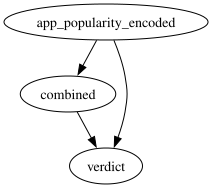

Common causes: ['app_popularity_encoded']
Effect modifiers: None
Estimator: backdoor.propensity_score_matching

------- Identified estimand -------
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                        
───────────(E[verdict|app_popularity_encoded])
d[combined]                                   
Estimand assumption 1, Unconfoundedness: If U→{combined} and U→verdict then P(verdict|combined,app_popularity_encoded,U) = P(verdict|combined,app_popularity_encoded)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                                        
───────────(E[verdict|app_popularity_encoded])
d[combined]                                   
Estimand assumption 1, Unconfoundedness: If U→{combined} and U→verdict then P(verdict|com

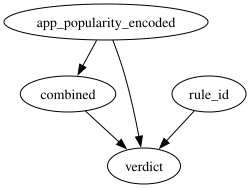

Common causes: ['app_popularity_encoded']
Effect modifiers: ['rule_id_gitlab_find_sec_bugs_RSA_NO_PADDING_1', 'rule_id_java_lang_security_audit_cbc_padding_oracle_cbc_padding_oracle', 'rule_id_java_lang_security_audit_crypto_des_is_deprecated_des_is_deprecated', 'rule_id_java_lang_security_audit_crypto_desede_is_deprecated_desede_is_deprecated', 'rule_id_java_lang_security_audit_crypto_ecb_cipher_ecb_cipher', 'rule_id_java_lang_security_audit_crypto_no_null_cipher_no_null_cipher', 'rule_id_java_lang_security_audit_crypto_no_static_initialization_vector_no_static_initialization_vector', 'rule_id_java_lang_security_audit_crypto_rsa_no_padding_rsa_no_padding', 'rule_id_java_lang_security_audit_crypto_ssl_avoid_implementing_custom_digests_avoid_implementing_custom_digests', 'rule_id_java_lang_security_audit_crypto_ssl_defaulthttpclient_is_deprecated_defaulthttpclient_is_deprecated', 'rule_id_java_lang_security_audit_crypto_ssl_insecure_hostname_verifier_insecure_hostname_verifier', 'rule_i

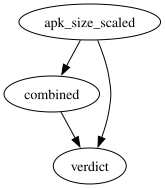

Common causes: ['apk_size_scaled']
Effect modifiers: None
Estimator: backdoor.propensity_score_matching

------- Identified estimand -------
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                 
───────────(E[verdict|apk_size_scaled])
d[combined]                            
Estimand assumption 1, Unconfoundedness: If U→{combined} and U→verdict then P(verdict|combined,apk_size_scaled,U) = P(verdict|combined,apk_size_scaled)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                                 
───────────(E[verdict|apk_size_scaled])
d[combined]                            
Estimand assumption 1, Unconfoundedness: If U→{combined} and U→verdict then P(verdict|combined,apk_size_scaled,U) = P(verdict|combined,apk_size_scaled)


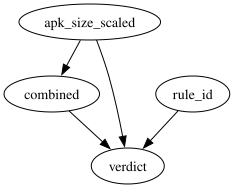

Common causes: ['apk_size_scaled']
Effect modifiers: ['rule_id_gitlab_find_sec_bugs_RSA_NO_PADDING_1', 'rule_id_java_lang_security_audit_cbc_padding_oracle_cbc_padding_oracle', 'rule_id_java_lang_security_audit_crypto_des_is_deprecated_des_is_deprecated', 'rule_id_java_lang_security_audit_crypto_desede_is_deprecated_desede_is_deprecated', 'rule_id_java_lang_security_audit_crypto_ecb_cipher_ecb_cipher', 'rule_id_java_lang_security_audit_crypto_no_null_cipher_no_null_cipher', 'rule_id_java_lang_security_audit_crypto_no_static_initialization_vector_no_static_initialization_vector', 'rule_id_java_lang_security_audit_crypto_rsa_no_padding_rsa_no_padding', 'rule_id_java_lang_security_audit_crypto_ssl_avoid_implementing_custom_digests_avoid_implementing_custom_digests', 'rule_id_java_lang_security_audit_crypto_ssl_defaulthttpclient_is_deprecated_defaulthttpclient_is_deprecated', 'rule_id_java_lang_security_audit_crypto_ssl_insecure_hostname_verifier_insecure_hostname_verifier', 'rule_id_java_

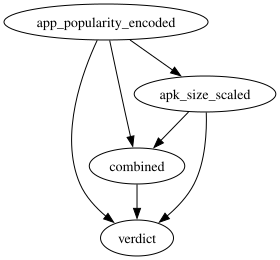

Common causes: ['apk_size_scaled', 'app_popularity_encoded']
Effect modifiers: None
Estimator: backdoor.propensity_score_matching

------- Identified estimand -------
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                        
───────────(E[verdict|apk_size_scaled,app_popularity_encoded])
d[combined]                                                   
Estimand assumption 1, Unconfoundedness: If U→{combined} and U→verdict then P(verdict|combined,apk_size_scaled,app_popularity_encoded,U) = P(verdict|combined,apk_size_scaled,app_popularity_encoded)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                                                        
───────────(E[verdict|apk_size_scaled,app_popularity_encoded])
d[com

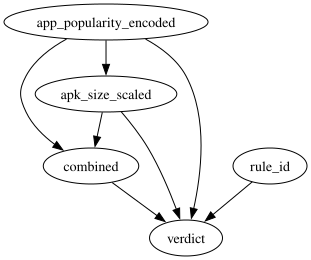

Common causes: ['apk_size_scaled', 'app_popularity_encoded']
Effect modifiers: ['rule_id_gitlab_find_sec_bugs_RSA_NO_PADDING_1', 'rule_id_java_lang_security_audit_cbc_padding_oracle_cbc_padding_oracle', 'rule_id_java_lang_security_audit_crypto_des_is_deprecated_des_is_deprecated', 'rule_id_java_lang_security_audit_crypto_desede_is_deprecated_desede_is_deprecated', 'rule_id_java_lang_security_audit_crypto_ecb_cipher_ecb_cipher', 'rule_id_java_lang_security_audit_crypto_no_null_cipher_no_null_cipher', 'rule_id_java_lang_security_audit_crypto_no_static_initialization_vector_no_static_initialization_vector', 'rule_id_java_lang_security_audit_crypto_rsa_no_padding_rsa_no_padding', 'rule_id_java_lang_security_audit_crypto_ssl_avoid_implementing_custom_digests_avoid_implementing_custom_digests', 'rule_id_java_lang_security_audit_crypto_ssl_defaulthttpclient_is_deprecated_defaulthttpclient_is_deprecated', 'rule_id_java_lang_security_audit_crypto_ssl_insecure_hostname_verifier_insecure_hostname

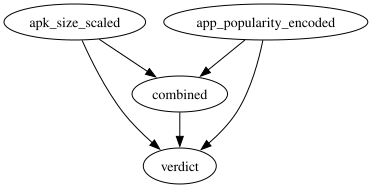

Common causes: ['apk_size_scaled', 'app_popularity_encoded']
Effect modifiers: None
Estimator: backdoor.propensity_score_matching

------- Identified estimand -------
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                        
───────────(E[verdict|apk_size_scaled,app_popularity_encoded])
d[combined]                                                   
Estimand assumption 1, Unconfoundedness: If U→{combined} and U→verdict then P(verdict|combined,apk_size_scaled,app_popularity_encoded,U) = P(verdict|combined,apk_size_scaled,app_popularity_encoded)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                                                        
───────────(E[verdict|apk_size_scaled,app_popularity_encoded])
d[com

In [15]:
analysis_results = []
for config in GRAPH_CONFIGS:
    analysis_results.append(run_causal_analysis(config))


In [16]:
summary_rows = []
refutation_rows = []

for result in analysis_results:
    summary_rows.append({
        "graph": result["graph"],
        "estimator": result["estimator"],
        "estimate": result["estimate"],
        "common_causes": ", ".join(result["common_causes"]),
        "effect_modifier_count": len(result["effect_modifiers"]),
    })
    for refutation in result["refutations"]:
        refutation_rows.append({
            "graph": result["graph"],
            **refutation,
        })

summary_df = pd.DataFrame(summary_rows)
refutation_df = pd.DataFrame(refutation_rows)

print("\n" + "=" * 35 + " Estimate Summary " + "=" * 35)
print(summary_df)

print("\n" + "=" * 35 + " Refutation Summary " + "=" * 35)
print(refutation_df)



=================================== Estimate Summary ===================================
                                               graph  \
0                 Graph 1: app popularity confounder   
1  Graph 2: app popularity confounder with rule_i...   
2                       Graph 3: APK size confounder   
3  Graph 4: APK size confounder with rule_id effe...   
4   Graph 5: APK size and app popularity confounders   
5  Graph 6: APK size and app popularity confounde...   
6  Graph 7: APK size and app popularity confounde...   

                            estimator  estimate  \
0  backdoor.propensity_score_matching -0.215657   
1  backdoor.propensity_score_matching -0.215657   
2  backdoor.propensity_score_matching  0.105015   
3  backdoor.propensity_score_matching  0.105015   
4  backdoor.propensity_score_matching  0.108563   
5  backdoor.propensity_score_matching  0.108563   
6  backdoor.propensity_score_matching  0.108563   

                             common_causes  effect_m